DAY 3: BUILDING RANDOM FOREST FROM SCRATCH

TESTING RANDOM FOREST ON IRIS

🌳 Training 50 decision trees...
  Training tree 1/50
  Training tree 21/50
  Training tree 41/50
✅ Random Forest trained with 50 trees

📊 Random Forest Accuracy: 0.9667 (96.7%)

📊 Comparison:
  Single Decision Tree: 0.9667 (96.7%)
  Random Forest (50 trees): 0.9667 (96.7%)

  📍 Random Forest matches single tree (dataset is simple)

EFFECT OF NUMBER OF TREES ON ACCURACY

🌳 Training 1 decision trees...
  Training tree 1/1
✅ Random Forest trained with 1 trees
    1 trees: 0.9333 (93.3%)

🌳 Training 5 decision trees...
  Training tree 1/5
✅ Random Forest trained with 5 trees
    5 trees: 0.9333 (93.3%)

🌳 Training 10 decision trees...
  Training tree 1/10
✅ Random Forest trained with 10 trees
   10 trees: 0.9000 (90.0%)

🌳 Training 20 decision trees...
  Training tree 1/20
✅ Random Forest trained with 20 trees
   20 trees: 0.9000 (90.0%)

🌳 Training 50 decision trees...
  Training tree 1/50
  Training tree 21/50
  T

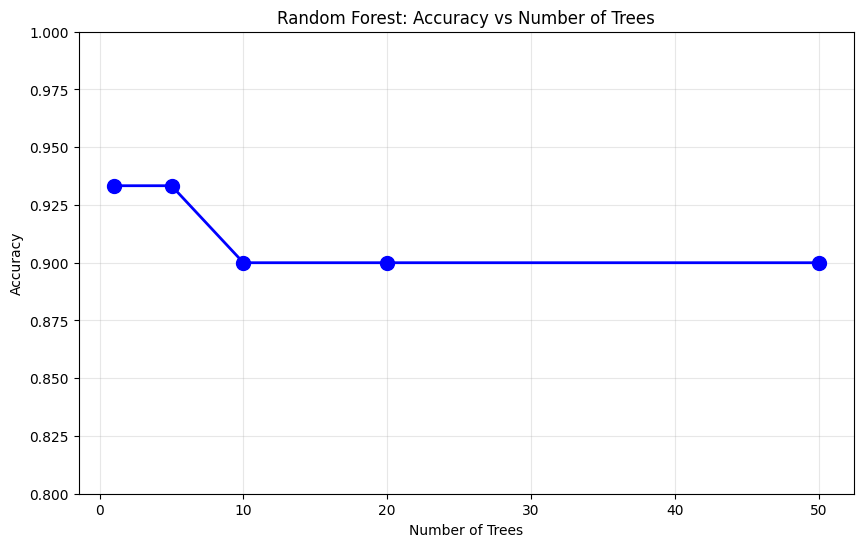


✅ RANDOM FOREST FROM SCRATCH COMPLETE!


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

print("=" * 60)
print("DAY 3: BUILDING RANDOM FOREST FROM SCRATCH")
print("=" * 60)

# ============================================
# PART 1: DECISION TREE CLASS
# ============================================

class DecisionTreeFromScratch:
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.tree = None
        self.n_features = None

    def _gini(self, y):
        """Calculate Gini impurity"""
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _information_gain(self, y_parent, y_left, y_right):
        """Calculate information gain"""
        gini_parent = self._gini(y_parent)
        n_parent = len(y_parent)
        n_left = len(y_left)
        n_right = len(y_right)

        weighted_gini = (n_left / n_parent) * self._gini(y_left) + \
                        (n_right / n_parent) * self._gini(y_right)

        return gini_parent - weighted_gini

    def _best_split_for_feature(self, X_feature, y):
        """Find best threshold for a single feature"""
        unique_values = np.unique(X_feature)

        if len(unique_values) == 1:
            return None, 0

        best_gain = 0
        best_threshold = None

        for i in range(len(unique_values) - 1):
            threshold = (unique_values[i] + unique_values[i+1]) / 2

            left_mask = X_feature <= threshold
            right_mask = X_feature > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = self._information_gain(y, y_left, y_right)

            if gain > best_gain:
                best_gain = gain
                best_threshold = threshold

        return best_threshold, best_gain

    def _find_best_split(self, X, y):
        """Find best feature and threshold to split on"""
        n_samples, n_features = X.shape

        # Determine how many features to try
        if self.max_features is None:
            n_try_features = n_features
        elif isinstance(self.max_features, str) and self.max_features == 'sqrt':
            n_try_features = int(np.sqrt(n_features))
        elif isinstance(self.max_features, str) and self.max_features == 'log2':
            n_try_features = int(np.log2(n_features))
        else:
            n_try_features = int(self.max_features)

        n_try_features = max(1, min(n_try_features, n_features))

        # Randomly select features to consider
        feature_indices = np.random.choice(n_features, n_try_features, replace=False)

        best_feature = None
        best_threshold = None
        best_gain = 0

        for feature_idx in feature_indices:
            X_feature = X[:, feature_idx]
            threshold, gain = self._best_split_for_feature(X_feature, y)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        """Recursively build the decision tree"""
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # Stopping conditions
        if n_classes == 1:
            return {'type': 'leaf', 'class': y[0], 'n_samples': n_samples}

        if self.max_depth is not None and depth >= self.max_depth:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        if n_samples < self.min_samples_split:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        # Find best split
        best_feature, best_threshold, best_gain = self._find_best_split(X, y)

        if best_feature is None or best_gain == 0:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        # Split the data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        X_left = X[left_mask]
        y_left = y[left_mask]
        X_right = X[right_mask]
        y_right = y[right_mask]

        # Recursively build children
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return {
            'type': 'node',
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_child,
            'right': right_child,
            'gain': best_gain,
            'n_samples': n_samples
        }

    def fit(self, X, y):
        """Train the decision tree"""
        self.n_features = X.shape[1]
        self.tree = self._build_tree(X, y)
        return self

    def _predict_single(self, x, node):
        """Predict a single sample"""
        if node['type'] == 'leaf':
            return node['class']

        if x[node['feature']] <= node['threshold']:
            return self._predict_single(x, node['left'])
        else:
            return self._predict_single(x, node['right'])

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self._predict_single(x, self.tree) for x in X])


# ============================================
# PART 2: RANDOM FOREST CLASS
# ============================================

class RandomForestFromScratch:
    def __init__(self, n_trees=100, max_depth=None, min_samples_split=2, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def _bootstrap_sample(self, X, y):
        """Create a bootstrap sample (sample with replacement)"""
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        """Train multiple decision trees on bootstrap samples"""
        print(f"\n🌳 Training {self.n_trees} decision trees...")

        for i in range(self.n_trees):
            if i % 20 == 0:
                print(f"  Training tree {i+1}/{self.n_trees}")

            # Create bootstrap sample
            X_sample, y_sample = self._bootstrap_sample(X, y)

            # Train a decision tree on the sample
            tree = DecisionTreeFromScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        print(f"✅ Random Forest trained with {self.n_trees} trees")
        return self

    def predict(self, X):
        """Predict by majority vote from all trees"""
        # Get predictions from all trees
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])

        # For each sample, find the most common prediction
        predictions = []
        for i in range(X.shape[0]):
            votes = tree_predictions[:, i]
            most_common = np.bincount(votes.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)

    def feature_importance(self, feature_names=None):
        """Calculate average feature importance across all trees"""
        n_features = self.trees[0].n_features
        total_importance = np.zeros(n_features)

        for tree in self.trees:
            importance = np.zeros(n_features)
            tree._accumulate_importance(tree.tree, importance)
            total_importance += importance

        # Normalize
        total_importance = total_importance / np.sum(total_importance)

        if feature_names is not None:
            print("\n🌳 RANDOM FOREST FEATURE IMPORTANCE:")
            print("=" * 40)
            for name, imp in zip(feature_names, total_importance):
                print(f"  {name:20s}: {imp:.4f}")

        return total_importance

# ============================================
# PART 3: TEST ON IRIS
# ============================================

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "=" * 60)
print("TESTING RANDOM FOREST ON IRIS")
print("=" * 60)

# Train Random Forest
rf = RandomForestFromScratch(n_trees=50, max_depth=5, min_samples_split=5)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 Random Forest Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

# Compare with single decision tree
single_tree = DecisionTreeFromScratch(max_depth=5, min_samples_split=5)
single_tree.fit(X_train, y_train)
single_pred = single_tree.predict(X_test)
single_accuracy = accuracy_score(y_test, single_pred)

print(f"\n📊 Comparison:")
print(f"  Single Decision Tree: {single_accuracy:.4f} ({single_accuracy*100:.1f}%)")
print(f"  Random Forest (50 trees): {accuracy:.4f} ({accuracy*100:.1f}%)")

if accuracy > single_accuracy:
    print("\n  ✅ Random Forest is MORE ACCURATE!")
elif accuracy == single_accuracy:
    print("\n  📍 Random Forest matches single tree (dataset is simple)")
else:
    print("\n  ⚠️ Random Forest performed worse (try more trees or deeper trees)")


# ============================================
# PART 4: EXPERIMENT WITH NUMBER OF TREES
# ============================================

n_trees_list = [1, 5, 10, 20, 50]
accuracies = []

print("\n" + "=" * 60)
print("EFFECT OF NUMBER OF TREES ON ACCURACY")
print("=" * 60)

for n in n_trees_list:
    rf = RandomForestFromScratch(n_trees=n, max_depth=5, min_samples_split=5)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"  {n:3d} trees: {acc:.4f} ({acc*100:.1f}%)")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, accuracies, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs Number of Trees')
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.0)
plt.show()

print("\n" + "=" * 60)
print("✅ RANDOM FOREST FROM SCRATCH COMPLETE!")
print("=" * 60)

DAY 4: FEATURE IMPORTANCE WITH RANDOM FOREST

📊 Breast Cancer Dataset:
  Samples: 569
  Features: 30

TOP 10 MOST IMPORTANT FEATURES
   1. worst area               : 0.1383
   2. worst concave points     : 0.1330
   3. worst radius             : 0.1008
   4. mean concave points      : 0.0985
   5. worst perimeter          : 0.0722
   6. mean perimeter           : 0.0686
   7. mean radius              : 0.0675
   8. mean concavity           : 0.0574
   9. mean area                : 0.0506
  10. worst concavity          : 0.0315


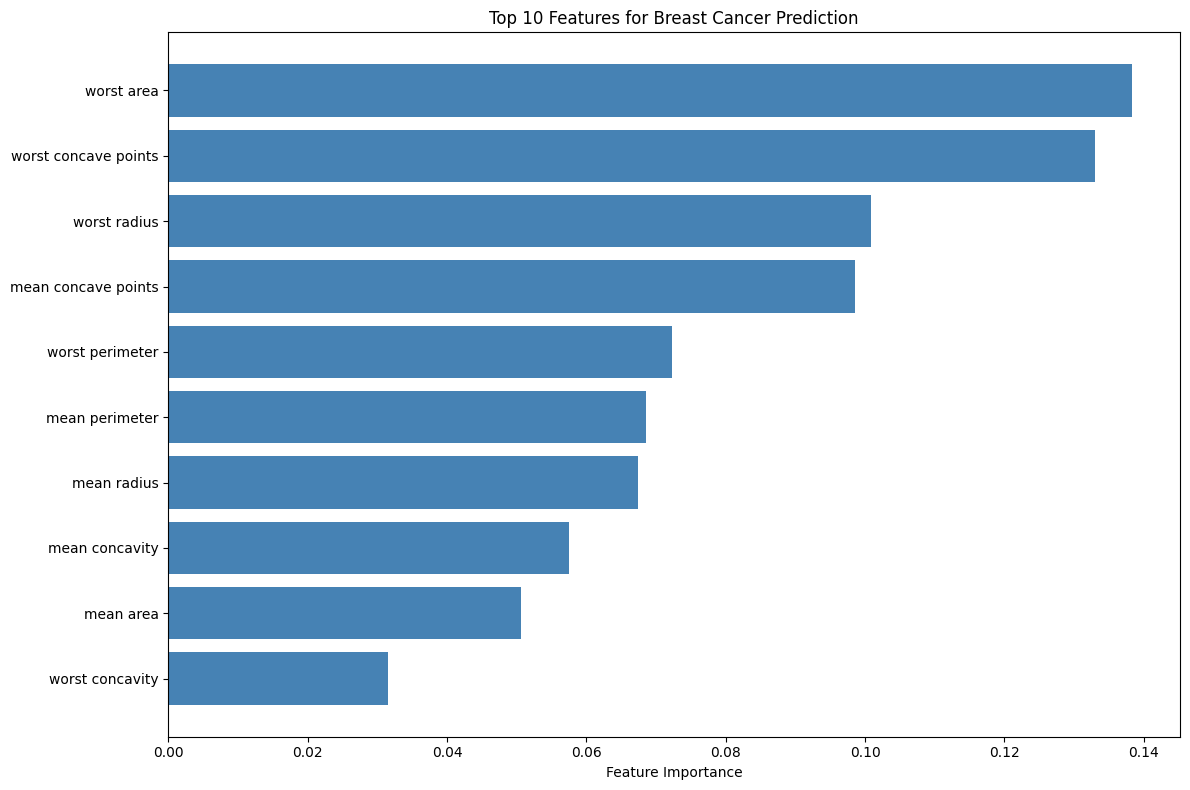


MODEL COMPARISON
All 30 features: 0.9561
Top 5 features only: 0.9298

💡 INSIGHT:
  Using only the 5 most important features achieved similar accuracy!
  This means we can simplify the model without losing performance.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("DAY 4: FEATURE IMPORTANCE WITH RANDOM FOREST")
print("=" * 60)

# Load a dataset where feature importance makes sense
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"\n📊 Breast Cancer Dataset:")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importance = rf.feature_importances_

# Sort features by importance
sorted_idx = np.argsort(importance)[::-1]

print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 60)

for i in range(10):
    idx = sorted_idx[i]
    print(f"  {i+1:2d}. {feature_names[idx]:25s}: {importance[idx]:.4f}")

# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(10), importance[sorted_idx[:10]][::-1], color='steelblue')
plt.yticks(range(10), [feature_names[i] for i in sorted_idx[:10]][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Features for Breast Cancer Prediction')
plt.tight_layout()
plt.show()

# Train with only top 5 features
top5_idx = sorted_idx[:5]
X_train_top5 = X_train[:, top5_idx]
X_test_top5 = X_test[:, top5_idx]

rf_top5 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"All 30 features: {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print(f"Top 5 features only: {accuracy_top5:.4f}")

print("\n💡 INSIGHT:")
print("  Using only the 5 most important features achieved similar accuracy!")
print("  This means we can simplify the model without losing performance.")